# 🎓 Das Redes Multicamadas (MLP) às Redes Neurais Convolucionais (CNN)
**Disciplina:** REDES NEURAIS ARTIFICIAIS, DEEP LEARNING E ALGORITMOS GENÉTICOS

**Curso:** Tecnólogo em Inteligência Artificial

---

## 🎯 Objetivos de Aprendizagem

Ao final desta aula prática, você será capaz de:
1. **Compreender** as limitações estruturais do Perceptron Multicamadas (MLP) no processamento de dados com relações espaciais (imagens).
2. **Explicar** os fundamentos e o funcionamento passo a passo das **Redes Neurais Convolucionais (CNNs)**: filtros, convoluções, *stride*, *padding* e *pooling*.
3. **Analisar** como os mecanismos de convolução e pooling lidam com **invariância a deslocamentos (*shifts*)** e reduzem a dimensionalidade da entrada.
4. **Construir** uma CNN completa no Keras integrando os conceitos de **BatchNormalization**, **Dropout** e **EarlyStopping** consolidados na aula anterior.
5. **Visualizar** e **interpretar** os mapas de características (*feature maps*) intermediários para entender o que os filtros da rede enxergam.

---

#### MLP para Classificação de imagens

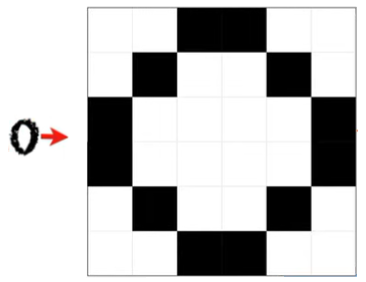

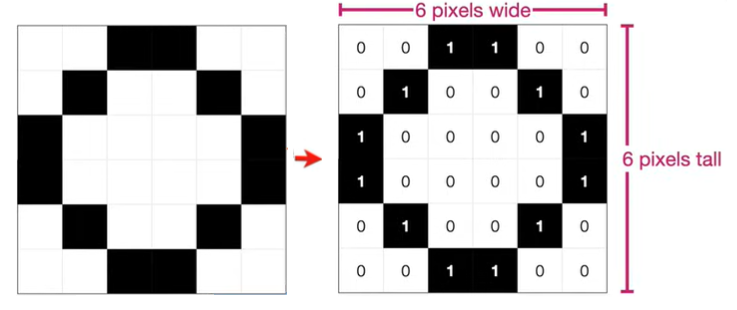

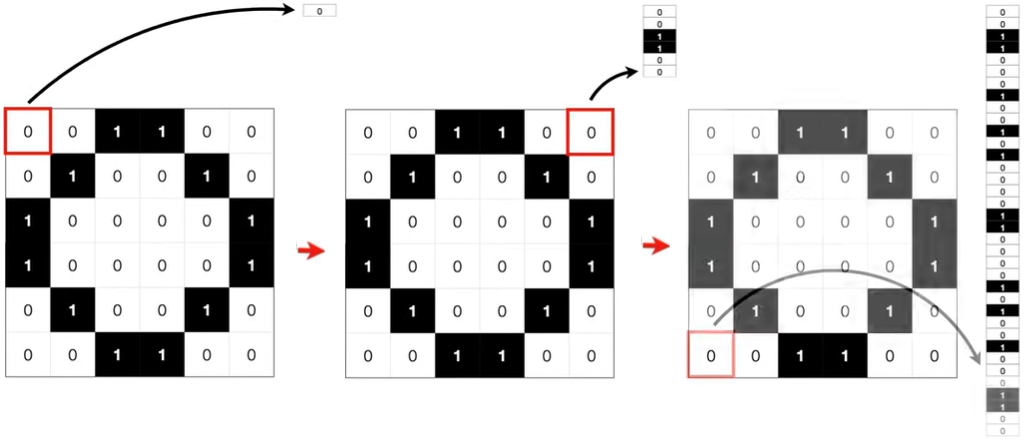

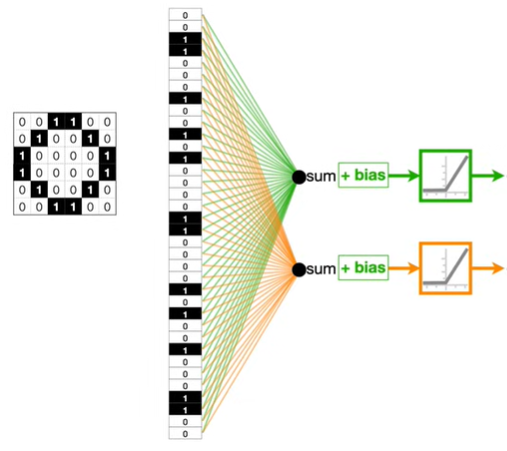

### Redes Neurais Convolucionais (CNN) para Classificação de imagens

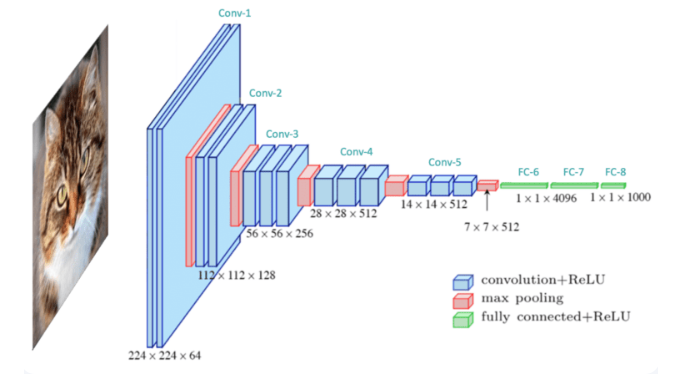

#### Convolução

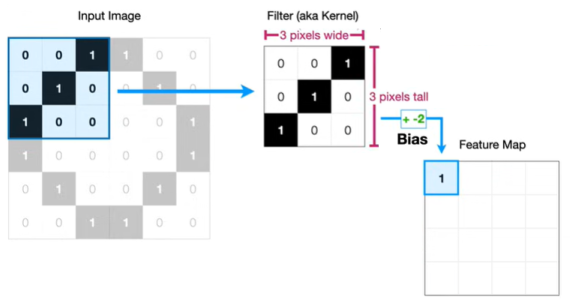

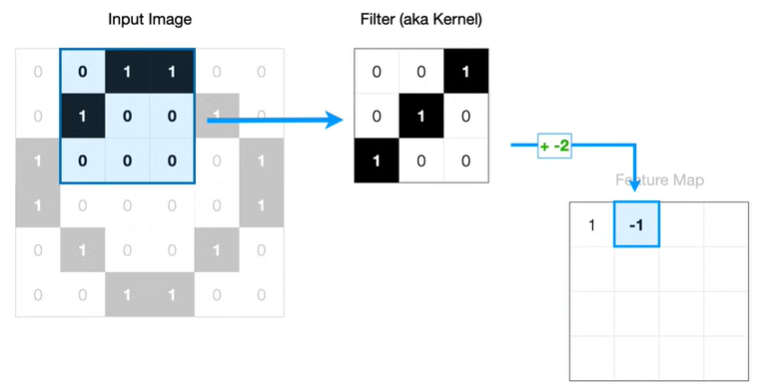

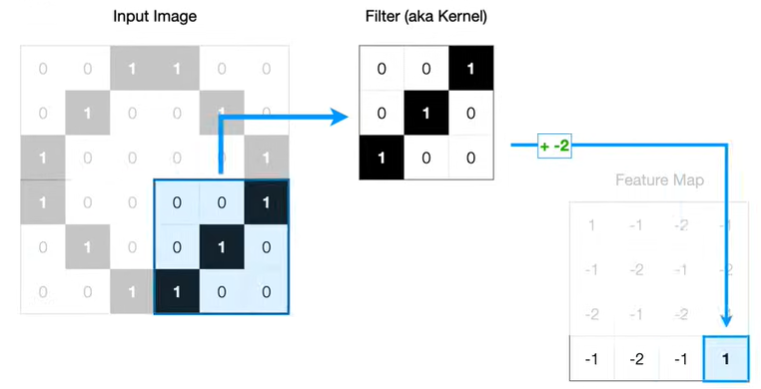

#### Cada célula do Feature Map corresponde a um grupo de pixels

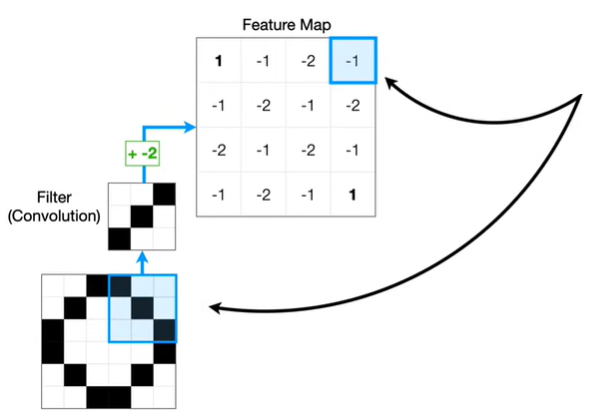

#### Função de atiação na CNN

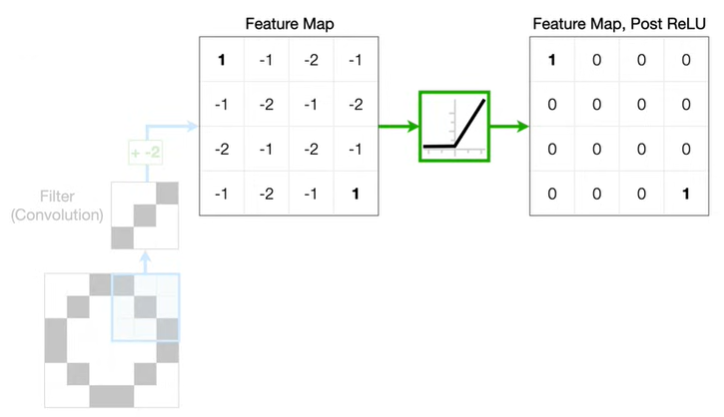

#### Pooling

##### Max Pooling

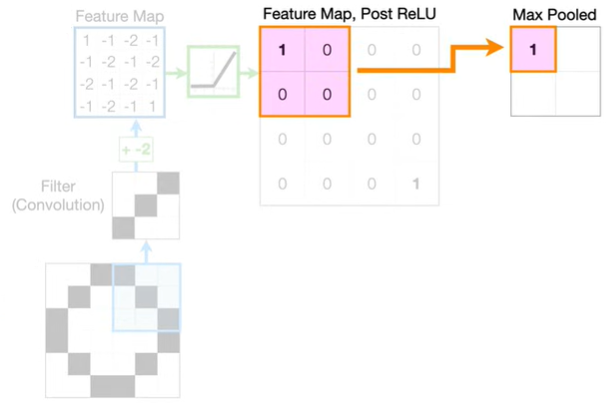

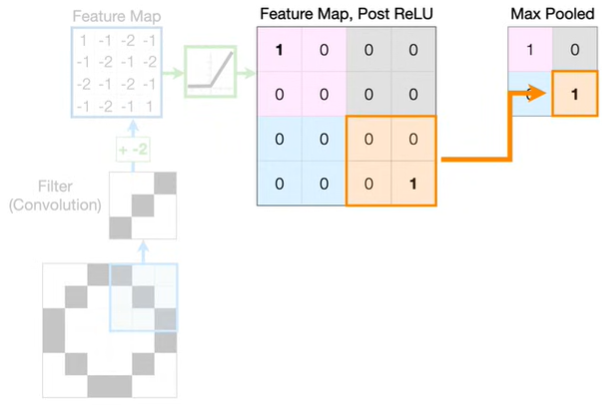

#### Mean Pooling

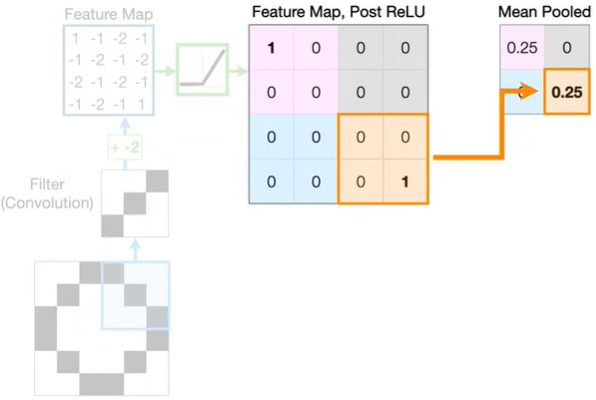

#### Alimentando a rede neural após a convolução e pooling

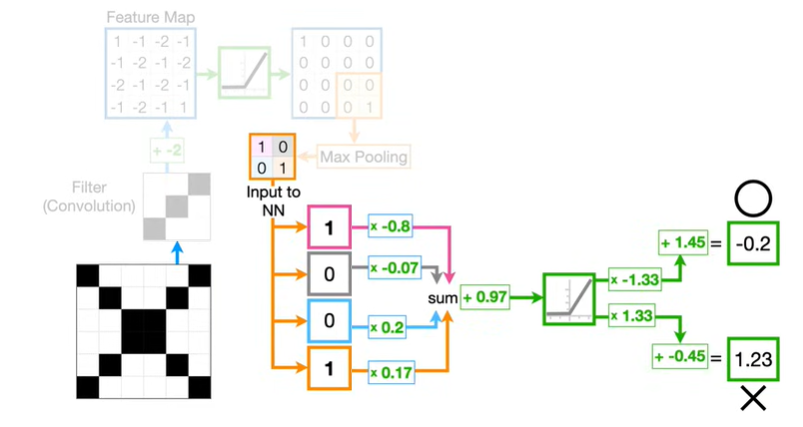

## 1. Configuração do Ambiente e Carga do Dataset

Nesta aula, utilizaremos o dataset **Fashion-MNIST**. Trata-se de um conjunto de dados real com 70.000 imagens em escala de cinza ($28 \times 28$ pixels) divididas em 10 categorias de vestuário.

### Por que usar o Fashion-MNIST nesta aula?
- É mais realista e desafiador que o MNIST tradicional de dígitos numéricos.
- Possui dimensões compactas ($28 \times 28$), permitindo treinos rápidos no Google Colab.
- Requer apenas pré-processamento simples: normalização dos pixels para o intervalo $[0.0, 1.0]$.

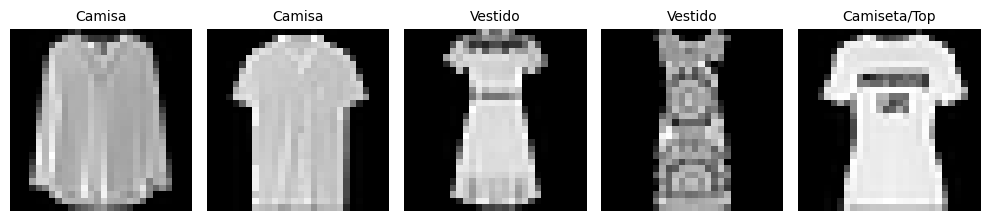

Formato de X_train: (48000, 28, 28) -> (Treino: 48000 amostras)
Formato de X_val:   (12000, 28, 28) -> (Validação: 12000 amostras)
Formato de X_test:  (10000, 28, 28) -> (Teste: 10000 amostras)

Classe          | Treino (%)   | Validação (%)  | Teste (%) 
Camiseta/Top    |      10.00% |        10.00% |     10.00%
Calça           |      10.00% |        10.00% |     10.00%
Pullover        |      10.00% |        10.00% |     10.00%
Vestido         |      10.00% |        10.00% |     10.00%
Casaco          |      10.00% |        10.00% |     10.00%
Sandália        |      10.00% |        10.00% |     10.00%
Camisa          |      10.00% |        10.00% |     10.00%
Tênis           |      10.00% |        10.00% |     10.00%
Bolsa           |      10.00% |        10.00% |     10.00%
Bota            |      10.00% |        10.00% |     10.00%


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Carregar o dataset Fashion-MNIST diretamente pelo Keras
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Nomes das classes para visualização intuitiva
class_names = ['Camiseta/Top', 'Calça', 'Pullover', 'Vestido', 'Casaco',
               'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

# 2. Divisão explícita em Treino (80%) e Validação (20%) com estratificação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

# 3. Pré-processamento mínimo: Normalização da escala de cinza (0-255 -> 0.0-1.0)
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 4. Visualização de algumas amostras do conjunto de dados de treino
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"{class_names[y_train[i]]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# 5. Formato de cada um dos conjuntos
print(f"Formato de X_train: {X_train.shape} -> (Treino: {len(X_train)} amostras)")
print(f"Formato de X_val:   {X_val.shape} -> (Validação: {len(X_val)} amostras)")
print(f"Formato de X_test:  {X_test.shape} -> (Teste: {len(X_test)} amostras)\n")

# 6. Cálculo e exibição formatada da proporção das classes
def calcular_proporcoes(y):
    classes, contagens = np.unique(y, return_counts=True)
    proporcoes = (contagens / len(y)) * 100
    return dict(zip(classes, proporcoes))

prop_train = calcular_proporcoes(y_train)
prop_val = calcular_proporcoes(y_val)
prop_test = calcular_proporcoes(y_test)

print("=" * 65)
print(f"{'Classe':<15} | {'Treino (%)':<12} | {'Validação (%)':<14} | {'Teste (%)':<10}")
print("=" * 65)
for idx, nome in enumerate(class_names):
    print(f"{nome:<15} | {prop_train[idx]:>10.2f}% | {prop_val[idx]:>12.2f}% | {prop_test[idx]:>9.2f}%")
print("=" * 65)

## 2. O Ponto de Partida: Recapitulando a MLP da Aula Anterior

Na nossa última aula, utilizamos o seguinte código base de uma rede **Perceptron Multicamadas (MLP)**:

```python
model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.Dense(32, activation='relu', name='dense_3'),
    layers.Dense(1, activation='sigmoid', name='output')
], name='MLP_Baseline')
```

Para adaptar esse modelo ao nosso dataset atual (que possui 10 classes em vez de uma classificação binária), alteraremos a camada de saída para `Dense(10, activation='softmax')`.

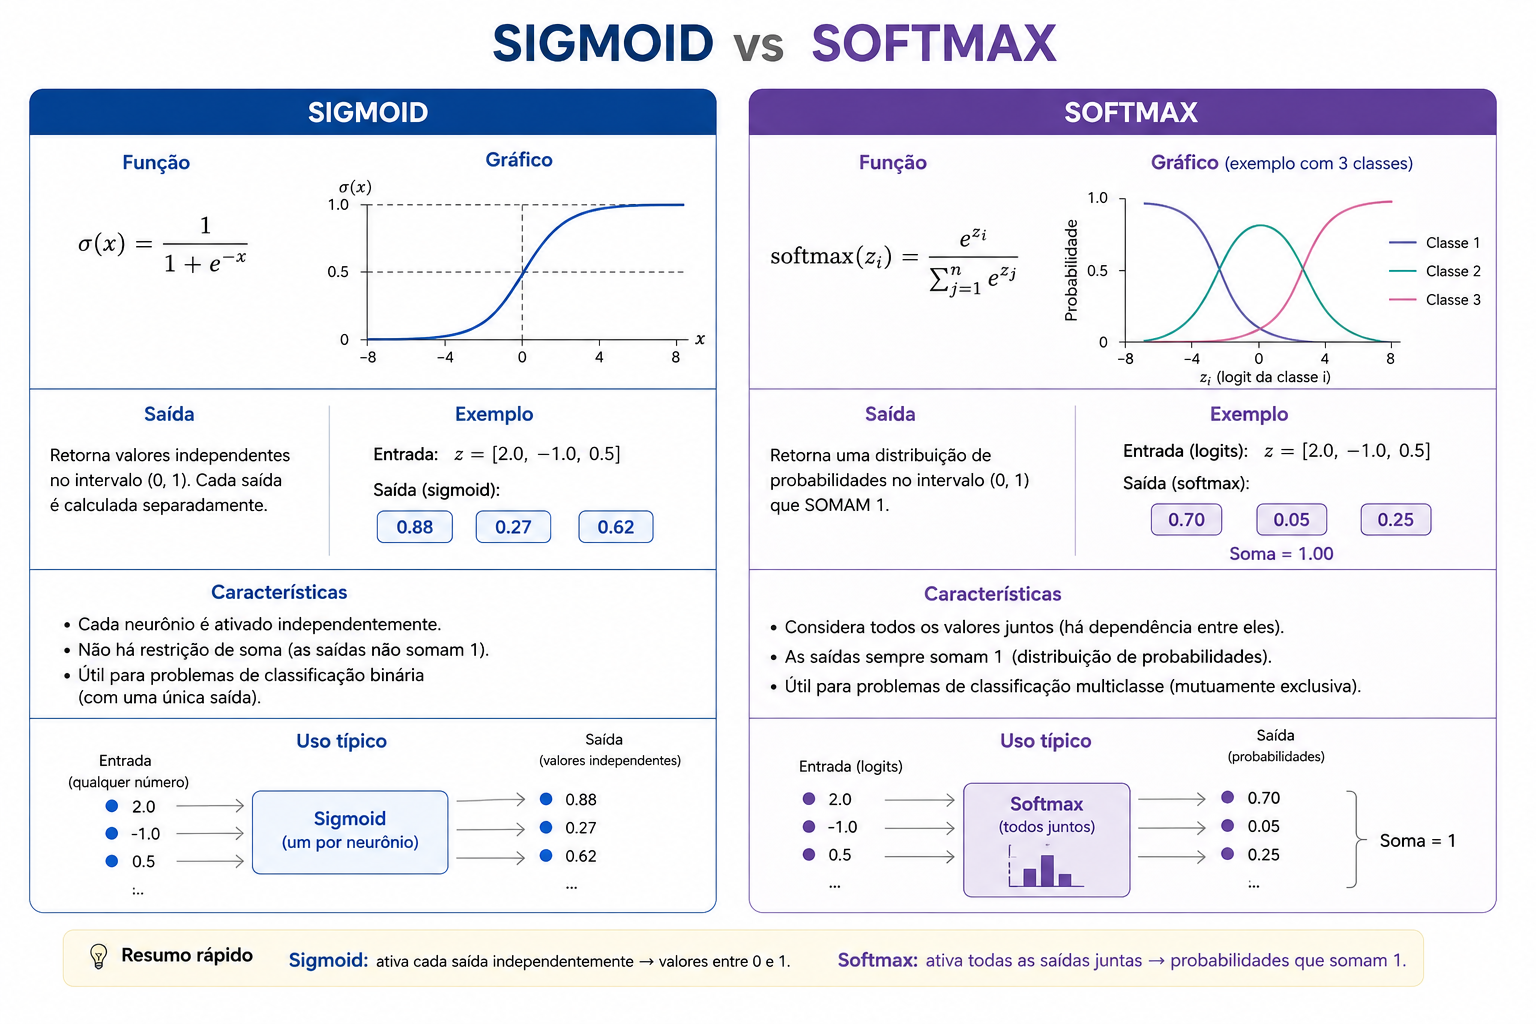

#### Loss para multi-classe

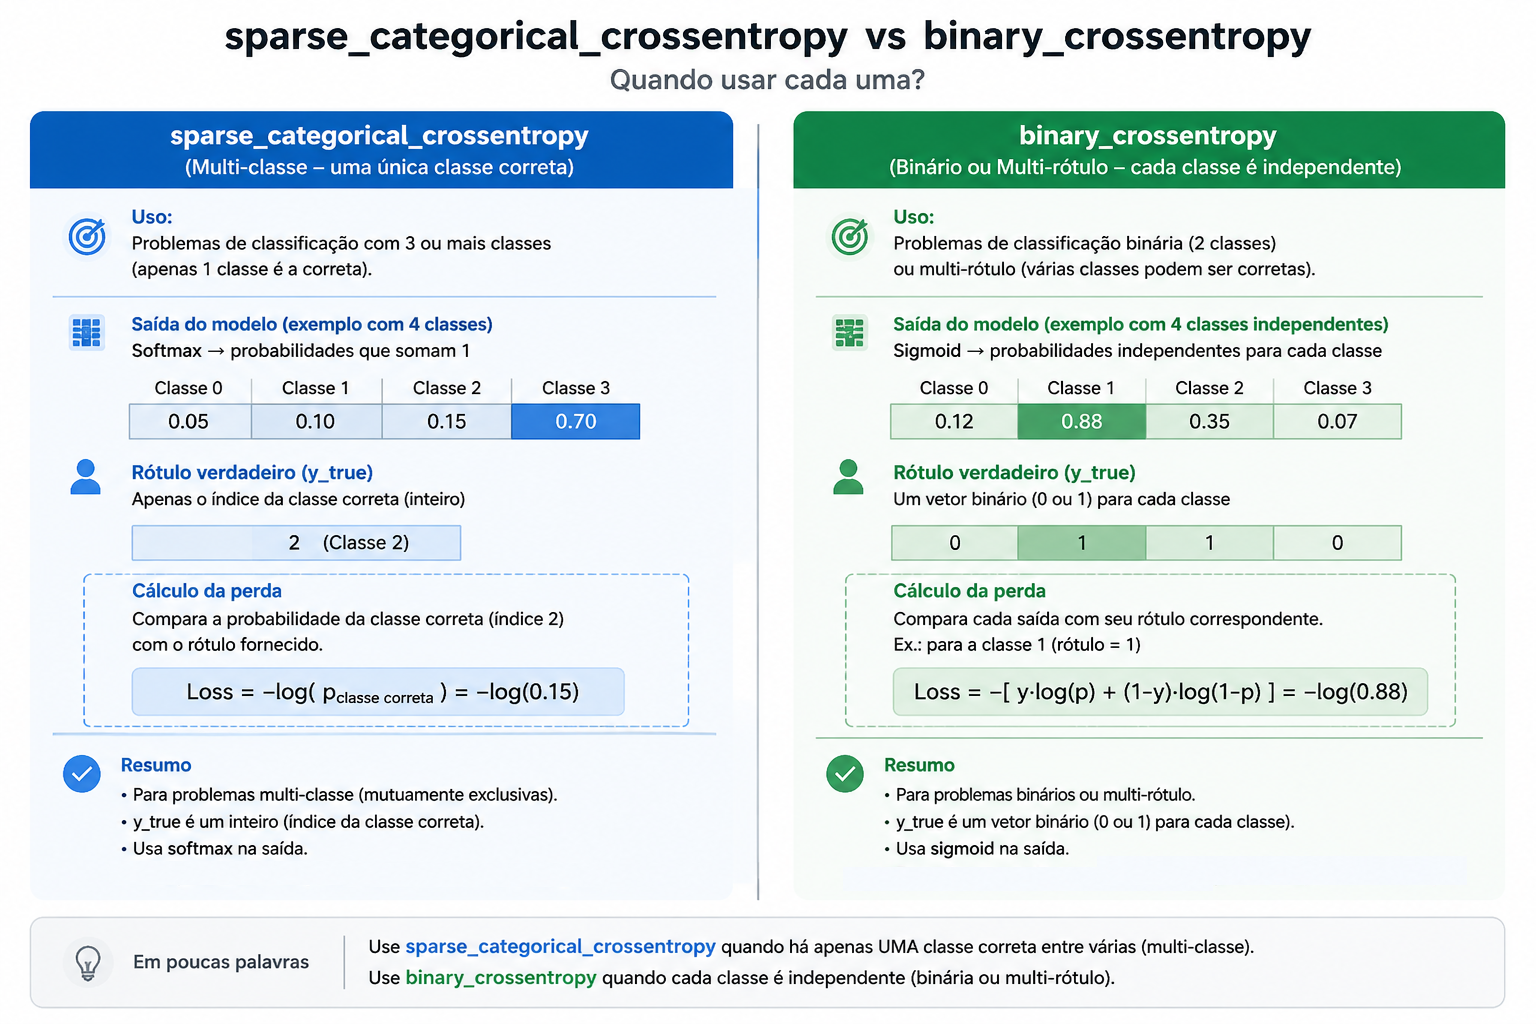

### ⚠️ As Limitações Fundamentais da MLP para Dados Visuais (Imagens):

1. **Perda de Relações Espaciais (*Flattening*):** Para alimentar uma camada `Dense`, precisamos achatar a matriz 2D ($28 \times 28$) em um vetor 1D de $784$ posições. Isso destrói a noções de vizinhança topológica (um pixel deixa de saber quem é seu vizinho de cima ou de baixo).
2. **Explosão do Número de Parâmetros:** Em uma camada `Dense`, cada neurônio conecta-se a **todos** os pixels de entrada. Para imagens de maior resolução (ex: $224 \times 224 \times 3$), a primeira camada teria mais de $150.000$ pesos por neurônio!
3. **Sensibilidade a Deslocamentos (*Shift Sensitivity*):** Se uma camiseta for movida apenas 2 pixels para a direita, o vetor 1D resultante muda drasticamente. A MLP não tem mecanismos nativos de invariância espacial.

In [ ]:
# Achatamento (Flatten) das imagens para alimentar a MLP (28x28 -> 784)
X_train_mlp = X_train.reshape((-1, 28 * 28))
X_val_mlp   = X_val.reshape((-1, 28 * 28))
X_test_mlp  = X_test.reshape((-1, 28 * 28))

input_dim = 28 * 28

# TODO Crie um Modelo MLP para servir de Baseline adaptando o
# modelo da Aula Anterior para 10 classes
mlp_baseline = ...


# TODO Compile o modelo usando optimizer='adam',
# loss='sparse_categorical_crossentropy' e metrics=['accuracy']
mlp_baseline.compile(...)

mlp_baseline.summary()

Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Conceito e Anatomia de uma CNN: Como Ela Resolve os Problemas da MLP?

A Rede Neural Convolucional introduz operadores projetados especificamente para preservar e explorar estruturas bidimensionais e tridimensionais.

### A. Filtros e Convolução (`Conv2D`)
- **Filtro (Kernel):** É uma pequena matriz de pesos (ex: $3 \times 3$) que desliza sobre a imagem calculando produtos escalares locais.
- **Conectividade Local (Local Receptive Field):** Cada neurônio convolucional é conectado apenas a uma pequena região da imagem, e não a ela inteira.
- **Compartilhamento de Pesos (Weight Sharing):** O **mesmo filtro** é aplicado em toda a extenso da imagem. Isso reduz o número de parâmetros de milhares para apenas algumas dezenas por filtro!
- **Extração de Hierarquia de Features:** Os primeiros filtros aprendem padrões simples (bordas, linhas, contrastes). Filtros mais profundos combinam esses elementos para reconhecer partes complexas (mangas, golas, solados).

### B. Camadas de Pooling (`MaxPooling2D` / `AveragePooling2D`)
- **Redução de Dimensionalidade:** Subamostra o mapa de características (*feature map*), reduzindo a largura e altura pela metade (ex: de $28 \times 28$ para $14 \times 14$).
- **Tratamento de Deslocamentos (*Shifts*):** O `MaxPooling2D` seleciona o valor máximo em cada janela (ex: $2 \times 2$). Se um padrão se mover levemente, o valor máximo capturado dentro da janela tende a permanecer o mesmo, conferindo **invariância à pequena translação**.
- **Redução da Carga Computacional:** Reduz a quantidade de dados que chegarão às camadas `Dense` finais.

## 4. Construindo a CNN (EarlyStopping, Dropout e BatchNormalization)

Para utilizar camadas Conv2D no Keras, precisamos explicitar o canal de cor na dimensão de entrada: (Altura, Largura, Canais). Como as imagens do Fashion-MNIST são em escala de cinza, a forma será (28, 28, 1).

Na aula passada, aprendemos como evitar overfitting e estabilizar o aprendizado usando:
1. **BatchNormalization:** Normaliza os mapas de características entre as camadas, permitindo aprendizado mais estável e rápido.
2. **Dropout:** Desativa aleatoriamente conexões durante o treino. Em CNNs, costuma-se usar taxas mais baixas após blocos convolucionais ($0.25$) e mais elevadas nas camadas densas ($0.50$).
3. **EarlyStopping:** Monitora a perda de validação (`val_loss`) e interrompe o treino no momento ideal.

In [ ]:
# Expandir dimensão para incluir o canal de escala de cinza (28, 28, 1)
X_train_cnn = np.expand_dims(X_train, axis=-1)
X_val_cnn   = np.expand_dims(X_val, axis=-1)
X_test_cnn  = np.expand_dims(X_test, axis=-1)

# Construindo a CNN Incrementada com BatchNormalization e Dropout
cnn_enhanced = models.Sequential([
    # --- CAMADA DE ENTRADA ---
    # Define o formato do tensor de entrada: (Altura=28, Largura=28, Canais=1 [Escala de Cinza])
    # TODO Crie um camada Input com shape=(28, 28, 1)


    # =========================================================================
    # BLOCO CONVOLUCIONAL 1: Extração de Características de Baixo Nível (Bordas/Linhas)
    # =========================================================================

    # 1. Convolução 2D: Aplica 32 filtros de tamanho 3x3.
    #    - padding='same': Adiciona zeros nas bordas para manter a dimensão espacial em (28, 28).
    #    - Saída: Tensor de forma (28, 28, 32) -> 32 mapas de características.
    # TODO Crie uma camada de Convolução 2D com 32 filtros de tamanho 3x3 como mesmo padding com Conv2D


    # 2. Batch Normalization: Normaliza as saídas da convolução por lote (média 0, variância 1).
    #    - Estabiliza o gradiente, acelera a convergência e reduz a sensibilidade à inicialização dos pesos.
    # TODO Crie uma camada de normalização com BatchNormalization


    # 3. Ativação ReLU: Aplica a não-linearidade f(x) = max(0, x).
    #    - Zeram-se os valores negativos, permitindo que a rede aprenda padrões não-lineares complexos.
    # TODO Crie uma camda de ativação com a função de ativação relu


    # 4. Max Pooling: Desliza uma janela 2x2 pegando apenas o valor máximo.
    #    - Reduz a dimensão espacial pela metade: de (28, 28, 32) para (14, 14, 32).
    #    - Concede invariância a pequenos deslocamentos (shifts) e reduz o custo computacional.
    # TODO Crie uma cama de Max Pooling com uma janela 2x2 com MaxPooling2D


    # 5. Dropout (25%): Desativa aleatoriamente 25% dos neurônios deste bloco durante o treino.
    #    - Força a rede a aprender representações redundantes e previne overfitting em camadas convolucionais.
    # TODO Crie uma camada dropout com 25% de drop


    # =========================================================================
    # BLOCO CONVOLUCIONAL 2: Extração de Características Complexas (Formas/Texturas)
    # =========================================================================

    # 6. Convolução 2D: Aumenta a capacidade para 64 filtros 3x3.
    #    - Processa os 32 mapas vindos do bloco anterior e combina bordas para formar estruturas.
    #    - padding='same' mantém a dimensão espacial de entrada do bloco: (14, 14).
    #    - Saída: Tensor de forma (14, 14, 64).
    # TODO Crie uma camada de Convolução 2D com 64 filtros de tamanho 3x3 como mesmo padding com Conv2D


    # 7. Batch Normalization: Normaliza os 64 mapas de características antes da ativação.
    # TODO Crie uma camada de normalização com BatchNormalization


    # 8. Ativação ReLU: Introduz a não-linearidade no segundo bloco.
    # TODO Crie uma camda de ativação com a função de ativação relu


    # 9. Max Pooling: Reduz novamente a dimensão espacial pela metade.
    #    - De (14, 14, 64) para (7, 7, 64).
    # TODO Crie uma cama de Max Pooling com uma janela 2x2 com MaxPooling2D


    # 10. Dropout (25%): Mantém a regularização intermediária para conter co-adaptação de recursos.
    # TODO Crie uma camada dropout com 25% de drop


    # =========================================================================
    # CABEÇA DE CLASSIFICAÇÃO (MLP Densa)
    # =========================================================================

    # 11. Flatten (Achatamento): Converte o tensor 3D em um vetor unidimensional (1D).
    #     - Transição do espaço visual (2D) para a decisão da MLP (1D).
    #     - Cálculo: 7 x 7 x 64 = 3.136 elementos por amostra.
    # TODO Crie uma camada flatten para converter o output da última camada de
    # pooling para um vetor unidimensional com .Flatten


    # 12. Camada Densa (Fully Connected): 128 neurônios para combinação final de atributos.
    #     - Cada um dos 128 neurônios conecta-se a todas as 3.136 entradas.
    # TODO Crie uma camada totalmente conectada com 128 neurônios com .Dense


    # 13. Batch Normalization: Normaliza as combinações lineares antes da ativação da camada densa.
    # TODO Crie uma camada de normalização com BatchNormalization


    # 14. Ativação ReLU: Não-linearidade para a camada de decisão intermediária.
    # TODO Crie uma camda de ativação com a função de ativação relu


    # 15. Dropout (50%): Taxa de desativação mais agressiva na camada densa final.
    #     - Camadas totalmente conectadas têm a maior quantidade de parâmetros e risco elevado de memorização.
    # TODO Crie uma camada dropout com 50% de drop


    # 16. Camada de Saída: 10 neurônios correspondentes às 10 classes de roupas.
    #     - Ativação Softmax: Converte as saídas brutas (logits) em uma distribuição de probabilidade
    #       onde a soma de todas as 10 saídas equivale a 1.0 (100%).
    # TODO Crie uma camada de output da rede com 10 neurônios com .Dense


], name='CNN_Enhanced')


# TODO Compile o modelo usando optimizer='adam',
# loss='sparse_categorical_crossentropy' e metrics=['accuracy']
cnn_enhanced.compile(...)

# TODO Configurando o EarlyStopping para monitorar o val_loss,
# com patience=10, min_delta=1e-5 e restore_best_weights=True
early_stop = ...

cnn_enhanced.summary()

Model: "CNN_Enhanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_1 (Activation)              │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_2 (Activation)              │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act_3 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,538 (1.61 MB)

 Trainable params: 422,090 (1.61 MB)

 Non-trainable params: 448 (1.75 KB)

## 6. Treinamento Comparativo: MLP vs CNN Incrementada

Agora colocaremos os dois modelos para treinar sob as mesmas condições e compararemos seu desempenho no conjunto de teste.

In [ ]:
# TODO Faça o Treinamento da MLP Baseline com .fit com X_train_mlp e y_train,
# validation_data=(X_val_mlp, y_val), epochs=15 e batch_size=64
# e com callbacks=[early_stop]
print("--- Treinando a MLP Baseline ---")
history_mlp = mlp_baseline.fit(...)

# TODO Faça o Treinamento da CNN com .fit com X_train_cnn e y_train
# validation_data=(X_val_mlp, y_val), epochs=15 e batch_size=64
# e com callbacks=[early_stop]
print("--- Treinando a CNN Incrementada ---")
history_cnn = cnn_enhanced.fit(...)

--- Treinando a MLP Baseline ---
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8086 - loss: 0.5414 - val_accuracy: 0.8658 - val_loss: 0.3878
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8620 - loss: 0.3823 - val_accuracy: 0.8736 - val_loss: 0.3494
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8754 - loss: 0.3425 - val_accuracy: 0.8848 - val_loss: 0.3184
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8837 - loss: 0.3182 - val_accuracy: 0.8941 - val_loss: 0.2860
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8898 - loss: 0.2985 - val_accuracy: 0.8947 - val_loss: 0.2890
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8945 - loss: 0.2866 - val_accuracy: 0.8989 - val_loss: 0.2734
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8971 - loss: 0.2771 - val_accuracy: 0.9077 - val_loss: 0.2524
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.902

In [ ]:
# Avaliação nos Dados de Teste
loss_mlp, acc_mlp = mlp_baseline.evaluate(X_test_mlp, y_test, verbose=0)
loss_cnn, acc_cnn = cnn_enhanced.evaluate(X_test_cnn, y_test, verbose=0)

print("="*55)
print(f"📊 Acurácia no Teste - MLP Baseline:      {acc_mlp*100:.2f}%")
print(f"📊 Acurácia no Teste - CNN Incrementada:  {acc_cnn*100:.2f}%")
print("="*55)

# Gráficos Comparativos das Curvas de Aprendizado
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Perda de Validação
axes[0].plot(history_mlp.history['val_loss'], label='MLP Baseline', linestyle='--', color='red')
axes[0].plot(history_cnn.history['val_loss'], label='CNN Enhanced', linewidth=2, color='blue')
axes[0].set_title('Perda de Validação (Validation Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Acurácia de Validação
axes[1].plot(history_mlp.history['val_accuracy'], label='MLP Baseline', linestyle='--', color='red')
axes[1].plot(history_cnn.history['val_accuracy'], label='CNN Enhanced', linewidth=2, color='blue')
axes[1].set_title('Acurácia de Validação (Validation Accuracy)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 1. Dicionário de Modelos a serem Comparados no Conjunto de Teste
# ==============================================================================
models_dict = {
    'MLP Baseline': mlp_baseline,       # Modelo MLP da aula anterior
    'CNN Regularizada': cnn_enhanced    # CNN com Dropout e BatchNormalization
}

# Lista para armazenar as métricas de avaliação
results = []

print("🚀 Avaliando os modelos no Conjunto de Teste (Dados Inéditos)...")
print("=" * 65)

# ==============================================================================
# 2. Loop de Avaliação no Conjunto de Teste
# ==============================================================================
for name, model in models_dict.items():
    # Verifica o formato de entrada esperado pelo modelo (MLP vs CNN)
    if len(model.input_shape) == 2:   # MLP espera entrada 1D: (None, 784)
        X_eval = X_test_mlp
    else:                             # CNN espera entrada 3D: (None, 28, 28, 1)
        X_eval = X_test_cnn

    # Avaliação oficial no conjunto de teste
    loss, accuracy = model.evaluate(X_eval, y_test, verbose=0)

    results.append({
        'Modelo': name,
        'Perda no Teste (Loss)': round(loss, 4),
        'Acurácia no Teste (%)': round(accuracy * 100, 2)
    })

# Criação do DataFrame com os resultados ordenados por acurácia
df_results = pd.DataFrame(results).sort_values(by='Acurácia no Teste (%)', ascending=False)

print("\n📊 TABELA COMPARATIVA DE DESEMPENHO NO TESTE:")
display(df_results)

# ==============================================================================
# 3. Visualização Gráfica do Desempenho
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Acurácia no Teste
sns.barplot(data=df_results, x='Modelo', y='Acurácia no Teste (%)', ax=axes[0], palette='viridis')
axes[0].set_title("Acurácia no Teste (%)")
axes[0].set_ylim(80, 100)
for patch in axes[0].patches:
    axes[0].annotate(f"{patch.get_height():.2f}%",
                      (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                      ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Perda (Loss) no Teste
sns.barplot(data=df_results, x='Modelo', y='Perda no Teste (Loss)', ax=axes[1], palette='magma')
axes[1].set_title("Perda (Loss) no Teste - Menor é Melhor")
for patch in axes[1].patches:
    axes[1].annotate(f"{patch.get_height():.4f}",
                      (patch.get_x() + patch.get_width() / 2., patch.get_height()),
                      ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. Detalhamento de Desempenho por Classe (Melhor Modelo)
# ==============================================================================
best_model_name = df_results.iloc[0]['Modelo']
best_model = models_dict[best_model_name]

print("=" * 65)
print(f"🎯 DETALHAMENTO POR CLASSE DO MELHOR MODELO: [{best_model_name}]")
print("=" * 65)

# Seleção da entrada adequada para o melhor modelo
X_eval_best = X_test_mlp if len(best_model.input_shape) == 2 else X_test_cnn

# Predição de probabilidades e conversão para a classe final
y_pred_probs = best_model.predict(X_eval_best, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Exibição do relatório de classificação (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Matriz de Confusão - {best_model_name}", fontsize=12)
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha='right')
plt.show()

## 7. O que a CNN Enxerga? (Visualizando Feature Maps)

Para entender como os filtros extraem correlações espaciais, podemos extrair as respostas intermediárias (*feature maps*) dos filtros da primeira camada convolucional para uma imagem de teste.

In [ ]:
import matplotlib.pyplot as plt

# 1. Selecionar uma imagem do conjunto de teste
img_sample = X_test_cnn[0:1] # Forma: (1, 28, 28, 1)

# 2. Obter a camada convolucional e executá-la diretamente sobre a imagem
conv1_layer = cnn_enhanced.get_layer('conv_1')
feature_maps = conv1_layer(img_sample)

# Convertendo para array numpy caso seja um tensor
if hasattr(feature_maps, 'numpy'):
    feature_maps = feature_maps.numpy()

# 3. Visualizar a imagem original e os mapas dos primeiros 8 filtros
plt.figure(figsize=(12, 3))

# Imagem original
plt.subplot(1, 9, 1)
plt.imshow(img_sample[0, :, :, 0], cmap='gray')
plt.title("Original", fontsize=9)
plt.axis('off')

# Primeiros 8 feature maps
for i in range(8):
    plt.subplot(1, 9, i+2)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f"Filtro {i+1}", fontsize=8)
    plt.axis('off')

plt.suptitle("Visualização dos Feature Maps da 1ª Camada Convolucional (Conv2D)", fontsize=12)
plt.tight_layout()
plt.show()

### 🧐 Interpretando os Mapas de Características (*Feature Maps*)

O gráfico acima exibe a imagem original e a **saída de 8 filtros diferentes** da primeira camada convolucional (`conv_1`).

#### 1. O que é um Feature Map?
Um *Feature Map* (Mapa de Características) é o resultado da aplicação de um **filtro específico ($3 \times 3$)** deslizando sobre toda a imagem de entrada. Cada filtro funciona como um "detector de padrões" especializado.

---

#### 2. Como ler a Paleta de Cores (`viridis`)?
- 🟨 **Regiões Claras (Amarelo / Verde Claro):** Representam **Alta Ativação**. O filtro encontrou o padrão exato que estava procurando naquela região da imagem (ex: uma borda vertical, um contorno de sola ou uma transição de iluminação).
- 🟪 **Regiões Escuras (Roxo / Azul Escuro):** Representam **Baixa ou Nula Ativação**. O padrão buscado por aquele filtro específico não está presente naquela região.

---

#### 3. Que tipo de padrão a 1ª Camada Convolucional aprendeu?
Observe como cada filtro foca em um aspecto visual diferente da peça:
* **Detecção de Bordas (Edges):** Alguns filtros destacam apenas as linhas do contorno externo da peça (ex: a silhueta do cano do sapato/bota).
* **Detecção de Gradiente/Brilho:** Outros filtros destacam regiões internas onde há variação brusca de contraste (ex: fivelas, cadarços ou dobras de tecido).
* **Filtros de Preenchimento/Massa:** Alguns destacam a textura interna da imagem como um todo.

---

#### 4. Por que a CNN é superior à MLP aqui?

1. **Compartilhamento de Pesos (*Weight Sharing*):** O filtro que detecta uma "borda vertical" no canto superior esquerdo é o **mesmo** que detecta essa mesma borda no canto inferior direito. Na MLP, seriam necessários milhares de pesos independentes para cobrir cada pixel individualmente.
2. **Preservação do Espaço:** A matriz gerada ($26 \times 26$) mantém a geometria 2D da imagem. Sabendo onde os amarelos (ativações) estão situados, as camadas seguintes conseguem combinar bordas em formas mais complexas (golas, solados, mangas).

## 8. Resumo Final

| Característica | Perceptron Multicamadas (MLP) | Rede Neural Convolucional (CNN) |
| :--- | :--- | :--- |
| **Entrada esperada** | Vetor Unidimensional 1D (`shape=(N,)`) | Tensor com estrutura espacial 2D/3D (`shape=(H, W, C)`) |
| **Tipo de Conexão** | Conexão Total (Cada neurônio ligado a tudo) | Conectividade Local (Filtros operam em vizinhanças) |
| **Garantia de Parâmetros** | Não (Explosão de pesos com imagens grandes) | Sim (Pesos compartilhados em toda a imagem) |
| **Preservação Espacial** | Destrói a geometria ao achatar a imagem | Preserva a relação topológica entre pixels vizinhos |
| **Tolerância a Deslocamentos** | Baixa (sensível a mudanças de posição) | Alta (Max/Average Pooling filtram pequenas variações) |
| **Regularizações Aplicadas** | EarlyStopping, Dropout, BatchNormalization | EarlyStopping, Dropout (em 2D e Dense), BatchNormalization |